# Multimodal Financial Forecasting Systems
### Armenian Deposit Dollarization Forecasting
### Student — Zvarth Aleksanyan
### ============================================================
### Models: HAR, VAR, LASSO, Ridge, Elastic Net, ARDL/ECM
### Sample: 169 monthly observations, 2012-2025
### Structural breaks: 2020-03, 2022-03
### ============================================================

In [1]:
# ── 0. IMPORTS ────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.rcParams.update({
    'figure.facecolor':'#1e1e1e','axes.facecolor':'#2d2d2d',
    'axes.edgecolor':'#555','text.color':'white',
    'axes.labelcolor':'white','xtick.color':'white','ytick.color':'white',
    'legend.facecolor':'#3d3d3d','grid.color':'#444','grid.alpha':0.4
})
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from xgboost import XGBRegressor

from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.ardl import ARDL, ardl_select_order
from statsmodels.tsa.api import VAR
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
import statsmodels.api as sm
from scipy import stats as scipy_stats

import os, shutil
np.random.seed(42)

print('All imports OK')
print(f'  numpy {np.__version__}  |  pandas {pd.__version__}')

All imports OK
  numpy 1.26.4  |  pandas 2.2.2


In [2]:
OUTPUT_DIR = r'Analysis/Outputs'
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Output folder: {OUTPUT_DIR}')

Output folder: Outputs


## Phase 1 — Data Loading & Feature Engineering


In [3]:
# ── Load raw data ─────────────────────────────────────────────────────
UPLOAD_PATH = '/mnt/user-data/uploads/Database_CBA_Rates and indicators.xlsx'
LOCAL_PATH  = 'Data/Structured/Database_CBA_Rates and indicators.xlsx'
path = UPLOAD_PATH if os.path.exists(UPLOAD_PATH) else LOCAL_PATH

df_raw = pd.read_excel(path)
df_raw.columns = (df_raw.columns.str.strip().str.lower()
                  .str.replace(' ','_').str.replace(r'[^a-z0-9_]','',regex=True))

print(f'Loaded: {df_raw.shape}  ({df_raw.shape[0]} months × {df_raw.shape[1]} columns)')
print(df_raw.columns.tolist())

Loaded: (169, 33)  (169 months × 33 columns)
['date', 'd1_cash_dollarization', 'd2_deposit_dollarization', 'd3_loan_dollarization', 'd4_broad_money_dollarization', 'd5_financial_dollarization', 'm2_amd', 'm2_total', 'currency_circulation', 'amd_demand_deposits', 'amd_time_deposits', 'fx_deposits_total', 'fx_demand_deposits', 'fx_time_deposits', 'total_deposits', 'loans_amd_residents', 'loans_fx_residents', 'total_loans', 'policy_rate', 'amd_deposit_rate', 'fx_deposit_rate', 'amd_lending_rate', 'fx_lending_rate', 'usd_amd', 'eur_amd', 'rub_amd', 'cpi', 'inflation', 'remittances', 'gir', 'reer', 'neer', 'eai_yoy']


In [4]:
# ──Parse dates & sort ────────────────────────────────────────────────
date_col = [c for c in df_raw.columns if any(k in c for k in ('date','month','year'))][0]
df_raw['Date'] = pd.to_datetime(df_raw[date_col])
df_raw = df_raw.sort_values('Date').reset_index(drop=True)
print(f'Date range: {df_raw.Date.min().date()} → {df_raw.Date.max().date()}')
print(f'N = {len(df_raw)} monthly observations')

Date range: 2012-01-31 → 2026-01-12
N = 169 monthly observations


In [5]:
# ── Missing value audit ─────────────────────────────────────────────
missing_cols = df_raw.columns[df_raw.isnull().any()].tolist()
for col in missing_cols:
    missing_idx   = df_raw[df_raw[col].isnull()].index
    missing_dates = df_raw.loc[missing_idx, 'Date'].dt.strftime('%Y-%m').tolist()
    print(f'  {col:<35} {len(missing_idx)} missing → {missing_dates}')


  d1_cash_dollarization               1 missing → ['2026-01']
  d2_deposit_dollarization            1 missing → ['2026-01']
  d3_loan_dollarization               1 missing → ['2026-01']
  d4_broad_money_dollarization        1 missing → ['2026-01']
  d5_financial_dollarization          1 missing → ['2026-01']
  m2_amd                              1 missing → ['2026-01']
  m2_total                            1 missing → ['2026-01']
  currency_circulation                1 missing → ['2026-01']
  amd_demand_deposits                 1 missing → ['2026-01']
  amd_time_deposits                   1 missing → ['2026-01']
  fx_deposits_total                   1 missing → ['2026-01']
  fx_demand_deposits                  1 missing → ['2026-01']
  fx_time_deposits                    1 missing → ['2026-01']
  total_deposits                      1 missing → ['2026-01']
  loans_amd_residents                 1 missing → ['2026-01']
  loans_fx_residents                  1 missing → ['2026-01']
  total_

In [34]:
# ── Feature engineering ───────────────────────────────────────────────────────
TARGET = 'd2_deposit_dollarization'

df = df_raw.copy()

# Rate differentials — incentive to hold AMD vs FX
df['deposit_rate_diff']  = df['amd_deposit_rate'] - df['fx_deposit_rate']
df['lending_rate_diff']  = df['amd_lending_rate'] - df['fx_lending_rate']

# Exchange rate dynamics
df['usd_return']         = np.log(df['usd_amd']).diff()
df['usd_volatility_6m']  = df['usd_return'].rolling(6,  min_periods=4).std()
df['usd_volatility_12m'] = df['usd_return'].rolling(12, min_periods=8).std()

# Ruble dynamics — remittance channel (Russia = ~60% of Armenian remittances)
df['rub_return']        = np.log(df['rub_amd']).diff()
df['rub_volatility_6m'] = df['rub_return'].rolling(6, min_periods=4).std()

# Gross International Reserves growth — CBA capacity to defend AMD
df['gir_growth']        = np.log(df['gir']).diff()

# Nominal Effective Exchange Rate — broader than just USD/AMD
df['neer_return']       = np.log(df['neer']).diff()

# shift(1) ensures no leakage — only uses past values
df['dol_lag1']          = df[TARGET].shift(1)
df['dol_lag3']          = df[TARGET].shift(1).rolling(3).mean()
df['dol_lag12']         = df[TARGET].shift(1).rolling(12).mean()

FEATURE_COLS = [
    'reer','amd_lending_rate','fx_lending_rate','amd_deposit_rate','fx_deposit_rate',
    'loans_fx_residents','remittances','policy_rate','inflation','usd_amd',
    'deposit_rate_diff','lending_rate_diff','usd_return',
    'usd_volatility_6m','usd_volatility_12m',
    'rub_return','rub_volatility_6m','gir_growth','neer_return','eai_yoy',
    'dol_lag1','dol_lag3','dol_lag12',
    TARGET
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

## Phase 2 — Structural Break Tests (Chow Test)
I test statistically whether breaks exist at 2020-03 and 2022-03 before deciding to include dummies.

In [35]:
# ── Chow Structural Break Test ───────────────────────────────────────
def chow_test(y, X, break_date_idx):
    """
    Chow test for structural break at break_date_idx.
    Tests whether regression coefficients differ before and after breakpoint.
    H0: No structural break (coefficients are stable)
    H1: Structural break exists at break_date_idx
    Reject H0 if p < 0.05 → dummy is statistically justified
    """
    n   = len(y)
    k   = X.shape[1]
    n1  = break_date_idx
    n2  = n - break_date_idx

    if n1 < k + 2 or n2 < k + 2:
        return np.nan, np.nan, 'Insufficient obs'

    # Full model RSS
    rss_full = np.sum(OLS(y, X).fit().resid ** 2)

    # Sub-period RSSs
    rss1 = np.sum(OLS(y[:n1], X[:n1]).fit().resid ** 2)
    rss2 = np.sum(OLS(y[n1:], X[n1:]).fit().resid ** 2)

    # Chow F-statistic
    f_stat = ((rss_full - rss1 - rss2) / k) / ((rss1 + rss2) / (n - 2 * k))
    p_val  = 1 - scipy_stats.f.cdf(f_stat, k, n - 2 * k)

    return f_stat, p_val

# Simple predictors for Chow test (avoid multicollinearity issues)
chow_vars = ['reer', 'deposit_rate_diff', 'usd_volatility_6m',
             'loans_fx_residents', 'inflation', 'policy_rate']
chow_vars = [v for v in chow_vars if v in df.columns]

df_chow = df[['Date', TARGET] + chow_vars].dropna().reset_index(drop=True)
y_chow  = df_chow[TARGET].values
X_chow  = add_constant(df_chow[chow_vars].values)

print('=== CHOW STRUCTURAL BREAK TESTS ===\n')
print(f'Testing on {len(df_chow)} observations with {len(chow_vars)} predictors\n')

break_candidates = {
    '2020-03 (COVID)':  '2020-03-01',
    '2022-03 (AMD shock)': '2022-03-01',
}

chow_results = {}
for label, date_str in break_candidates.items():
    break_idx = df_chow[df_chow['Date'] >= date_str].index[0]
    n1        = break_idx
    n2        = len(df_chow) - break_idx
    f_stat, p_val = chow_test(y_chow, X_chow, break_idx)

    verdict = '✅ BREAK CONFIRMED — dummy justified' if p_val < 0.05 \
              else '❌ No break — dummy NOT justified'

    chow_results[label] = {
        'Break date': date_str,
        'Obs before': n1,
        'Obs after':  n2,
        'F-statistic': round(f_stat, 4),
        'p-value':     round(p_val, 4),
        'Verdict':     verdict
    }

    print(f'Break point: {label}')
    print(f'  Observations before: {n1}  |  after: {n2}')
    print(f'  F-statistic : {f_stat:.4f}')
    print(f'  p-value     : {p_val:.4f}')
    print(f'  {verdict}\n')

chow_df = pd.DataFrame(chow_results).T
display(chow_df)

# ── Decide which dummies to include based on test results ─────────────────────
include_2020 = chow_results['2020-03 (COVID)']['p-value']   < 0.05
include_2022 = chow_results['2022-03 (AMD shock)']['p-value'] < 0.05

print('\n=== DUMMY DECISION ===')
print(f'  post_2020: {"INCLUDE" if include_2020 else "EXCLUDE"} (p={chow_results["2020-03 (COVID)"]["p-value"]:.4f})')
print(f'  post_2022: {"INCLUDE" if include_2022 else "EXCLUDE"} (p={chow_results["2022-03 (AMD shock)"]["p-value"]:.4f})')

=== CHOW STRUCTURAL BREAK TESTS ===

Testing on 164 observations with 6 predictors

Break point: 2020-03 (COVID)
  Observations before: 94  |  after: 70
  F-statistic : 75.3520
  p-value     : 0.0000
  ✅ BREAK CONFIRMED — dummy justified

Break point: 2022-03 (AMD shock)
  Observations before: 118  |  after: 46
  F-statistic : 19.6611
  p-value     : 0.0000
  ✅ BREAK CONFIRMED — dummy justified



,Break date,Obs before,Obs after,F-statistic,p-value,Verdict
2020-03 (COVID),2020-03-01,94,70,75.352,0.0,✅ BREAK CONFIRMED — dummy justified
2022-03 (AMD shock),2022-03-01,118,46,19.6611,0.0,✅ BREAK CONFIRMED — dummy justified



=== DUMMY DECISION ===
  post_2020: INCLUDE (p=0.0000)
  post_2022: INCLUDE (p=0.0000)


In [36]:
# Creating dummies for the dates
if include_2020:
    df['post_2020'] = (df['Date'] >= '2020-03-01').astype(int)
    FEATURE_COLS.append('post_2020')

if include_2022:
    df['post_2022']       = (df['Date'] >= '2022-03-01').astype(int)
    df['reer_x_break']    = df['reer']       * df['post_2022']
    df['usd_ret_x_break'] = df['usd_return'] * df['post_2022']
    FEATURE_COLS.extend(['post_2022','reer_x_break','usd_ret_x_break'])

print('Updated FEATURE_COLS:')
print(FEATURE_COLS)

Updated FEATURE_COLS:
['reer', 'amd_lending_rate', 'fx_lending_rate', 'amd_deposit_rate', 'fx_deposit_rate', 'loans_fx_residents', 'remittances', 'policy_rate', 'inflation', 'usd_amd', 'deposit_rate_diff', 'lending_rate_diff', 'usd_return', 'usd_volatility_6m', 'usd_volatility_12m', 'rub_return', 'rub_volatility_6m', 'gir_growth', 'neer_return', 'eai_yoy', 'dol_lag1', 'dol_lag3', 'dol_lag12', 'd2_deposit_dollarization', 'post_2020', 'post_2022', 'reer_x_break', 'usd_ret_x_break']


## Phase 3 — EDA & Variable Selection


In [37]:
# ──Stationarity tests ────────────────────────────────────────────────
def adf_kpss(series, name):
    s = series.dropna()
    adf_stat, adf_p = adfuller(s, autolag='AIC')[:2]
    try:
        kpss_stat, kpss_p = kpss(s, regression='c', nlags='auto')[:2]
    except:
        kpss_stat, kpss_p = np.nan, np.nan
    adf_r  = 'Stationary'     if adf_p  < 0.05 else 'Non-stationary'
    kpss_r = 'Stationary'     if kpss_p >= 0.05 else 'Non-stationary'
    return {
        'Variable': name,
        'ADF_stat': round(adf_stat, 4), 'ADF_p': round(adf_p, 4),   'ADF':  adf_r,
        'KPSS_stat':round(kpss_stat,4), 'KPSS_p':round(kpss_p,4),   'KPSS': kpss_r,
        'Consensus':'Stationary' if adf_r == kpss_r == 'Stationary' else 'Non-stationary'
    }

stat_df = pd.DataFrame([adf_kpss(df[c], c) for c in FEATURE_COLS if c in df.columns])
print('=== Stationarity Tests ===')
display(stat_df)

=== Stationarity Tests ===


C:\Users\HP\AppData\Local\Temp\ipykernel_15112\2073541745.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p = kpss(s, regression='c', nlags='auto')[:2]
C:\Users\HP\AppData\Local\Temp\ipykernel_15112\2073541745.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p = kpss(s, regression='c', nlags='auto')[:2]
C:\Users\HP\AppData\Local\Temp\ipykernel_15112\2073541745.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p = kpss(s, regression='c', nlags='auto')[:2]
C:\Users\HP\AppData\Local\Temp\ipykernel_15112\2073541745.py:6: InterpolationWarning: The test statistic is outside

,Variable,ADF_stat,ADF_p,ADF,KPSS_stat,KPSS_p,KPSS,Consensus
0,reer,-0.7995,0.8193,Non-stationary,1.5377,0.0100,Non-stationary,Non-stationary
1,amd_lending_rate,-1.5815,0.4929,Non-stationary,1.3563,0.0100,Non-stationary,Non-stationary
2,fx_lending_rate,-2.0262,0.2752,Non-stationary,1.5772,0.0100,Non-stationary,Non-stationary
3,amd_deposit_rate,-1.7132,0.4243,Non-stationary,0.9932,0.0100,Non-stationary,Non-stationary
4,fx_deposit_rate,-1.0629,0.7297,Non-stationary,1.6678,0.0100,Non-stationary,Non-stationary
5,loans_fx_residents,0.2763,0.9762,Non-stationary,1.5483,0.0100,Non-stationary,Non-stationary
6,remittances,-2.4395,0.1309,Non-stationary,0.3539,0.0970,Stationary,Non-stationary
7,policy_rate,-1.9482,0.3097,Non-stationary,0.2077,0.1000,Stationary,Non-stationary
8,inflation,-2.4798,0.1205,Non-stationary,0.0327,0.1000,Stationary,Non-stationary
9,usd_amd,-1.3394,0.6110,Non-stationary,0.4608,0.0510,Stationary,Non-stationary


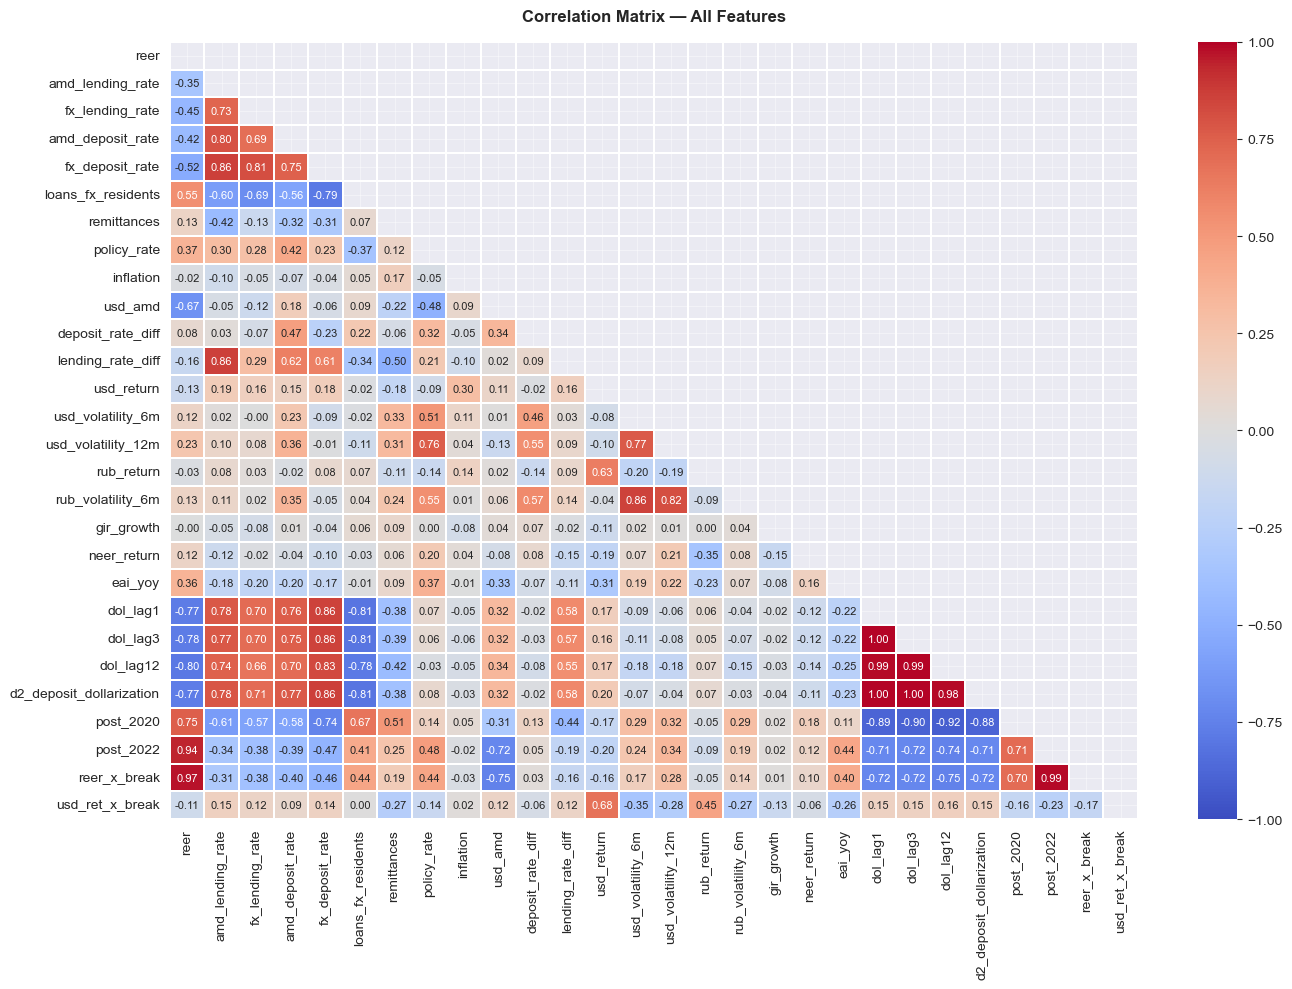


Top correlations with d2_deposit_dollarization:
dol_lag1              0.997
dol_lag3              0.995
dol_lag12             0.985
post_2020             0.884
fx_deposit_rate       0.861
loans_fx_residents    0.809
amd_lending_rate      0.785
reer                  0.772
amd_deposit_rate      0.769
reer_x_break          0.718
post_2022             0.711
fx_lending_rate       0.710
Name: d2_deposit_dollarization, dtype: float64


In [38]:
# ──Correlation heatmap ───────────────────────────────────────────────
plot_cols = [c for c in FEATURE_COLS if c in df.columns]
corr_mat  = df[plot_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.3, ax=ax, annot_kws={'size':8})
ax.set_title('Correlation Matrix — All Features', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'correlation_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTop correlations with {TARGET}:')
print(corr_mat[TARGET].drop(TARGET).abs().sort_values(ascending=False).head(12).round(3))

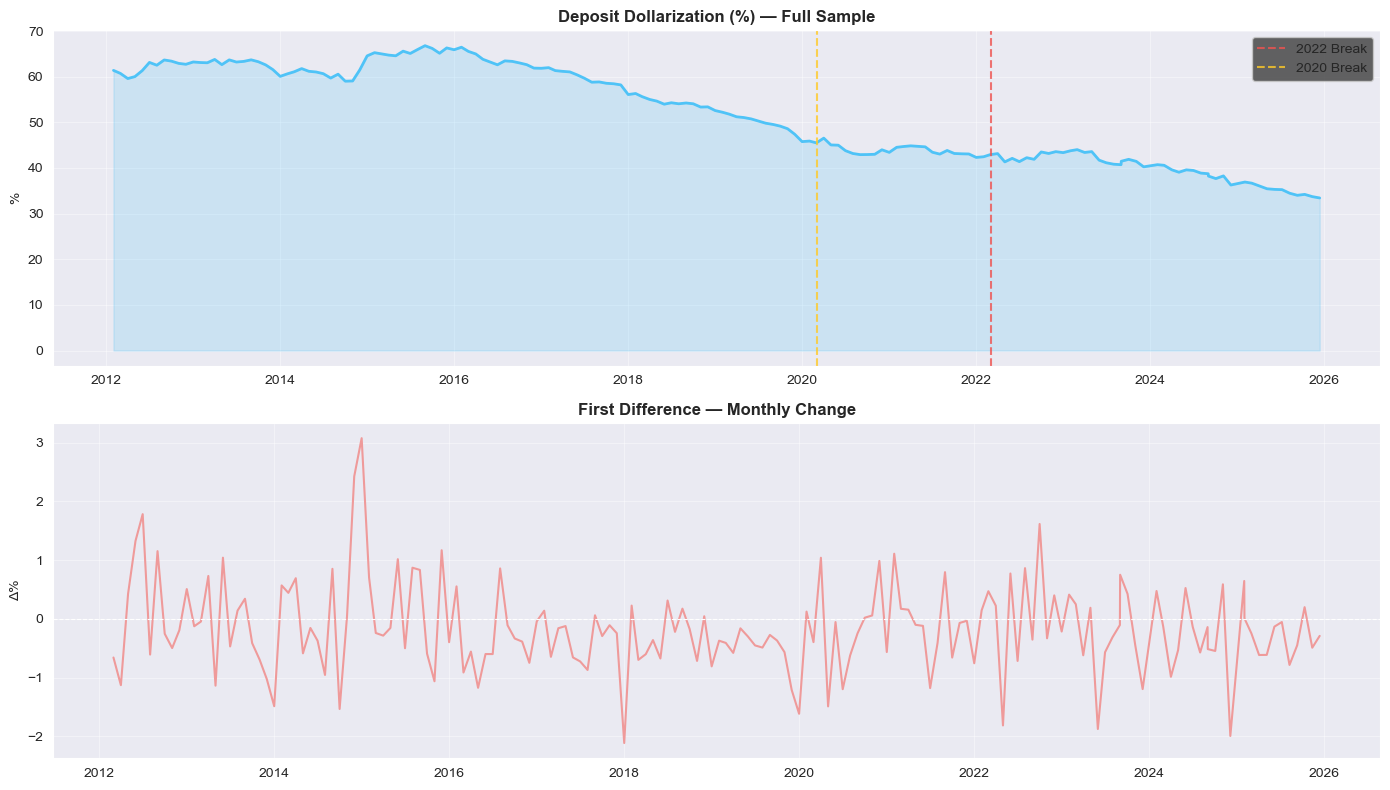

In [39]:
# ──Target variable over time ─────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df['Date'], df[TARGET], color='#4fc3f7', linewidth=2)
axes[0].fill_between(df['Date'], df[TARGET], alpha=0.2, color='#4fc3f7')
axes[0].axvline(pd.Timestamp('2022-03-01'), color='#ef5350',
                linewidth=1.5, linestyle='--', alpha=0.8, label='2022 Break')
if include_2020:
    axes[0].axvline(pd.Timestamp('2020-03-01'), color='#ffca28',
                    linewidth=1.5, linestyle='--', alpha=0.8, label='2020 Break')
axes[0].set_title('Deposit Dollarization (%) — Full Sample', fontweight='bold')
axes[0].set_ylabel('%'); axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].grid(True)

axes[1].plot(df['Date'], df[TARGET].diff(), color='#ef9a9a', linewidth=1.5)
axes[1].axhline(0, color='white', linewidth=0.8, linestyle='--')
axes[1].set_title('First Difference — Monthly Change', fontweight='bold')
axes[1].set_ylabel('Δ%')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'target_timeseries.png'), dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ──  VIF ───────────────────────────────────────────────────────────────
CANDIDATE_VARS = [c for c in FEATURE_COLS if c != TARGET and c in df.columns]
vif_data = df[CANDIDATE_VARS].dropna()
vif_df   = pd.DataFrame([{
    'Variable': col,
    'VIF': round(variance_inflation_factor(vif_data.values, i), 2)
} for i, col in enumerate(CANDIDATE_VARS)]).sort_values('VIF', ascending=False)
vif_df['Flag'] = vif_df['VIF'].apply(
    lambda x: 'HIGH' if x > 10 else ('MOD' if x > 5 else 'OK'))
print('=== Variance Inflation Factors ===')
display(vif_df)

=== Variance Inflation Factors ===


,Variable,VIF,Flag
10,deposit_rate_diff,inf,HIGH
2,fx_lending_rate,inf,HIGH
3,amd_deposit_rate,inf,HIGH
4,fx_deposit_rate,inf,HIGH
1,amd_lending_rate,inf,HIGH
11,lending_rate_diff,inf,HIGH
21,dol_lag3,29334.33,HIGH
20,dol_lag1,14543.37,HIGH
22,dol_lag12,9649.40,HIGH
9,usd_amd,1948.69,HIGH


In [40]:
# ──Granger causality ────────────────────────────────────────────────
GRANGER_VARS = ['reer','amd_lending_rate','loans_fx_residents','remittances',
                'deposit_rate_diff','usd_volatility_6m','policy_rate',
                'usd_return','inflation','fx_lending_rate']
GRANGER_VARS = [v for v in GRANGER_VARS if v in df.columns]

granger_rows = []
for var in GRANGER_VARS:
    sub = df[[TARGET, var]].dropna()
    if len(sub) < 30: continue
    try:
        res = grangercausalitytests(sub, maxlag=3, verbose=False)
        for lag in range(1, 4):
            p = res[lag][0]['ssr_ftest'][1]
            granger_rows.append({'Variable':var,'Lag':lag,
                                  'F_p':round(p,4),'Sig':'✅' if p<0.05 else ''})
    except: pass

granger_df = pd.DataFrame(granger_rows)
print('=== Granger Causality: X → Deposit Dollarization ===')
display(granger_df[granger_df['Sig']=='✅'])


=== Granger Causality: X → Deposit Dollarization ===


,Variable,Lag,F_p,Sig
9,remittances,1,0.0090,✅
10,remittances,2,0.0360,✅
11,remittances,3,0.0035,✅
15,usd_volatility_6m,1,0.0467,✅
27,fx_lending_rate,1,0.0465,✅
28,fx_lending_rate,2,0.0281,✅
29,fx_lending_rate,3,0.0368,✅


## Phase 4 — Modelling Dataset Setup


In [55]:
# ── Step 11: Build modelling dataset ─────────────────────────────────────────
# Core LASSO variables — selected based on economic theory + variable scorecard
LASSO_VARS = [
    'reer',
    'loans_fx_residents', 'remittances',
    'deposit_rate_diff', 'lending_rate_diff',
    'usd_volatility_6m', 'policy_rate',
    'usd_return', 'inflation',
    'rub_return', 'rub_volatility_6m',
    'gir_growth', 'neer_return',
    'eai_yoy',
    'dol_lag1', 'dol_lag3', 'dol_lag12',
]

# Add dummies only if Chow test confirmed them
if include_2022:
    LASSO_VARS = LASSO_VARS + ['post_2022', 'reer_x_break', 'usd_ret_x_break']

if include_2020:
    LASSO_VARS = LASSO_VARS + ['post_2020']

LASSO_VARS = [v for v in LASSO_VARS if v in df.columns]

df_model = df[['Date', TARGET] + LASSO_VARS].dropna().reset_index(drop=True)

print(f'Modelling dataset: {df_model.shape}')
print(f'Date range: {df_model.Date.min().date()} → {df_model.Date.max().date()}')
print(f'Variables ({len(LASSO_VARS)}): {LASSO_VARS}')

X_m  = df_model[LASSO_VARS].values
y_m  = df_model[TARGET].values
tscv = TimeSeriesSplit(n_splits=5, test_size=12)

Modelling dataset: (153, 23)
Date range: 2013-01-31 → 2025-09-09
Variables (21): ['reer', 'loans_fx_residents', 'remittances', 'deposit_rate_diff', 'lending_rate_diff', 'usd_volatility_6m', 'policy_rate', 'usd_return', 'inflation', 'rub_return', 'rub_volatility_6m', 'gir_growth', 'neer_return', 'eai_yoy', 'dol_lag1', 'dol_lag3', 'dol_lag12', 'post_2022', 'reer_x_break', 'usd_ret_x_break', 'post_2020']


## Phase 5 — Naive Benchmarks

In [56]:
# ── Naive benchmarks ─────────────────────────────────────────────────
# Random Walk: predict today = yesterday
# Rolling Mean: predict today = average of last 12 months

rw_preds   = np.full(len(y_m), np.nan)  # Random Walk
rm_preds   = np.full(len(y_m), np.nan)  # Rolling Mean (12m)
rw_metrics = []
rm_metrics = []

for fold, (tr, te) in enumerate(tscv.split(X_m)):
    # Random Walk: last training value carried forward
    rw_pred = np.full(len(te), y_m[tr[-1]])
    rw_preds[te] = rw_pred

    # Rolling Mean: mean of last 12 training observations
    rm_pred = np.full(len(te), np.mean(y_m[tr[-12:]]))
    rm_preds[te] = rm_pred

    rw_metrics.append({
        'Fold': fold+1,
        'RMSE': np.sqrt(mean_squared_error(y_m[te], rw_pred)),
        'MAE':  mean_absolute_error(y_m[te], rw_pred),
        'R²':   r2_score(y_m[te], rw_pred)
    })
    rm_metrics.append({
        'Fold': fold+1,
        'RMSE': np.sqrt(mean_squared_error(y_m[te], rm_pred)),
        'MAE':  mean_absolute_error(y_m[te], rm_pred),
        'R²':   r2_score(y_m[te], rm_pred)
    })

rw_df = pd.DataFrame(rw_metrics)
rm_df = pd.DataFrame(rm_metrics)
rw_df.loc['Mean'] = rw_df.mean()
rm_df.loc['Mean'] = rm_df.mean()

print('=== Random Walk Benchmark ===')
display(rw_df.round(4))
print('\n=== Rolling Mean (12m) Benchmark ===')
display(rm_df.round(4))


=== Random Walk Benchmark ===


,Fold,RMSE,MAE,R²
0,1.0,1.2162,1.0030,-2.1263
1,2.0,0.9854,0.7716,-1.1170
2,3.0,1.5411,1.0994,-0.6071
3,4.0,1.9261,1.6681,-2.2033
4,5.0,2.4418,2.1260,-3.0549
Mean,3.0,1.6221,1.3336,-1.8217



=== Rolling Mean (12m) Benchmark ===


,Fold,RMSE,MAE,R²
0,1.0,1.4426,1.2681,-3.3991
1,2.0,1.6339,1.4870,-4.8204
2,3.0,1.2200,1.1756,-0.0072
3,4.0,2.8986,2.6914,-6.2541
4,5.0,3.9577,3.7673,-9.6526
Mean,3.0,2.2306,2.0779,-4.8267


## Phase 6 — Linear Models (LASSO, Ridge, Elastic Net)


In [57]:
# ──LASSO walk-forward CV ────────────────────────────────────────────
lasso_preds     = np.full(len(y_m), np.nan)
lasso_fold_mets = []

binary_cols = [v for v in LASSO_VARS if 'post_' in v]
scale_cols  = [v for v in LASSO_VARS if v not in binary_cols]
scale_idx   = [LASSO_VARS.index(v) for v in scale_cols]

for fold, (tr, te) in enumerate(tscv.split(X_m)):
    scaler   = StandardScaler()
    X_tr_s   = X_m[tr].copy().astype(float)
    X_te_s   = X_m[te].copy().astype(float)
    scaler.fit(X_m[tr][:, scale_idx])
    X_tr_s[:, scale_idx] = scaler.transform(X_m[tr][:, scale_idx])
    X_te_s[:, scale_idx] = scaler.transform(X_m[te][:, scale_idx])

    lasso    = LassoCV(cv=5, max_iter=10000, random_state=42)
    lasso.fit(X_tr_s, y_m[tr])
    yp       = lasso.predict(X_te_s)

    lasso_preds[te] = yp
    r = {'Fold':fold+1,
         'RMSE': np.sqrt(mean_squared_error(y_m[te], yp)),
         'MAE':  mean_absolute_error(y_m[te], yp),
         'R²':   r2_score(y_m[te], yp),
         'Alpha':lasso.alpha_}
    lasso_fold_mets.append(r)
    print(f'  Fold {fold+1}: RMSE={r["RMSE"]:.4f}  MAE={r["MAE"]:.4f}  '
          f'R²={r["R²"]:.4f}  α={lasso.alpha_:.5f}')

lasso_cv_df = pd.DataFrame(lasso_fold_mets)
lasso_cv_df.loc['Mean'] = lasso_cv_df.mean()
lasso_cv_df.loc['Std']  = lasso_cv_df.std()
print('\n=== LASSO Walk-Forward CV ===')
display(lasso_cv_df.round(4))

  Fold 1: RMSE=1.4523  MAE=1.3165  R²=-3.4586  α=0.00670
  Fold 2: RMSE=0.9532  MAE=0.7701  R²=-0.9807  α=0.04747
  Fold 3: RMSE=1.0022  MAE=0.7977  R²=0.3202  α=0.05195
  Fold 4: RMSE=0.4344  MAE=0.3203  R²=0.8371  α=0.00884
  Fold 5: RMSE=0.7916  MAE=0.6803  R²=0.5739  α=0.00932

=== LASSO Walk-Forward CV ===


,Fold,RMSE,MAE,R²,Alpha
0,1.0000,1.4523,1.3165,-3.4586,0.0067
1,2.0000,0.9532,0.7701,-0.9807,0.0475
2,3.0000,1.0022,0.7977,0.3202,0.0519
3,4.0000,0.4344,0.3203,0.8371,0.0088
4,5.0000,0.7916,0.6803,0.5739,0.0093
Mean,3.0000,0.9267,0.7770,-0.5416,0.0249
Std,1.4142,0.3296,0.3192,1.5868,0.0204


In [58]:
# ──Ridge walk-forward CV ────────────────────────────────────────────
ridge_preds     = np.full(len(y_m), np.nan)
ridge_fold_mets = []
alphas          = np.logspace(-3, 4, 50)

binary_cols = [v for v in LASSO_VARS if 'post_' in v]
scale_cols  = [v for v in LASSO_VARS if v not in binary_cols]
scale_idx   = [LASSO_VARS.index(v) for v in scale_cols]

for fold, (tr, te) in enumerate(tscv.split(X_m)):
    scaler   = StandardScaler()
    X_tr_s   = X_m[tr].copy().astype(float)
    X_te_s   = X_m[te].copy().astype(float)
    scaler.fit(X_m[tr][:, scale_idx])
    X_tr_s[:, scale_idx] = scaler.transform(X_m[tr][:, scale_idx])
    X_te_s[:, scale_idx] = scaler.transform(X_m[te][:, scale_idx])

    ridge    = RidgeCV(alphas=alphas, cv=5)
    ridge.fit(X_tr_s, y_m[tr])
    yp       = ridge.predict(X_te_s)

    ridge_preds[te] = yp
    r = {'Fold':fold+1,
         'RMSE': np.sqrt(mean_squared_error(y_m[te], yp)),
         'MAE':  mean_absolute_error(y_m[te], yp),
         'R²':   r2_score(y_m[te], yp),
         'Alpha':ridge.alpha_}
    ridge_fold_mets.append(r)
    print(f'  Fold {fold+1}: RMSE={r["RMSE"]:.4f}  MAE={r["MAE"]:.4f}  '
          f'R²={r["R²"]:.4f}  α={ridge.alpha_:.4f}')

ridge_cv_df = pd.DataFrame(ridge_fold_mets)
ridge_cv_df.loc['Mean'] = ridge_cv_df.mean()
ridge_cv_df.loc['Std']  = ridge_cv_df.std()
print('\n=== Ridge Walk-Forward CV ===')
display(ridge_cv_df.round(4))

  Fold 1: RMSE=1.8806  MAE=1.6827  R²=-6.4756  α=0.0010
  Fold 2: RMSE=1.5820  MAE=1.2468  R²=-4.4562  α=1.9307
  Fold 3: RMSE=0.6432  MAE=0.5359  R²=0.7200  α=2.6827
  Fold 4: RMSE=0.4626  MAE=0.3820  R²=0.8153  α=0.0010
  Fold 5: RMSE=1.0351  MAE=0.9677  R²=0.2713  α=0.7197

=== Ridge Walk-Forward CV ===


,Fold,RMSE,MAE,R²,Alpha
0,1.0000,1.8806,1.6827,-6.4756,0.0010
1,2.0000,1.5820,1.2468,-4.4562,1.9307
2,3.0000,0.6432,0.5359,0.7200,2.6827
3,4.0000,0.4626,0.3820,0.8153,0.0010
4,5.0000,1.0351,0.9677,0.2713,0.7197
Mean,3.0000,1.1207,0.9630,-1.8251,1.0670
Std,1.4142,0.5401,0.4730,3.0461,1.0724


In [59]:
# ──Elastic Net walk-forward CV ──────────────────────────────────────
enet_preds     = np.full(len(y_m), np.nan)
enet_fold_mets = []
l1_ratios      = [0.1, 0.3, 0.5, 0.7, 0.9]

binary_cols = [v for v in LASSO_VARS if 'post_' in v]
scale_cols  = [v for v in LASSO_VARS if v not in binary_cols]
scale_idx   = [LASSO_VARS.index(v) for v in scale_cols]

for fold, (tr, te) in enumerate(tscv.split(X_m)):
    scaler   = StandardScaler()
    X_tr_s   = X_m[tr].copy().astype(float)
    X_te_s   = X_m[te].copy().astype(float)
    scaler.fit(X_m[tr][:, scale_idx])
    X_tr_s[:, scale_idx] = scaler.transform(X_m[tr][:, scale_idx])
    X_te_s[:, scale_idx] = scaler.transform(X_m[te][:, scale_idx])

    enet     = ElasticNetCV(l1_ratio=l1_ratios, cv=5,
                            max_iter=10000, random_state=42)
    enet.fit(X_tr_s, y_m[tr])
    yp       = enet.predict(X_te_s)

    enet_preds[te] = yp
    r = {'Fold':fold+1,
         'RMSE':     np.sqrt(mean_squared_error(y_m[te], yp)),
         'MAE':      mean_absolute_error(y_m[te], yp),
         'R²':       r2_score(y_m[te], yp),
         'Alpha':    round(enet.alpha_, 5),
         'L1_ratio': round(enet.l1_ratio_, 3)}
    enet_fold_mets.append(r)
    print(f'  Fold {fold+1}: RMSE={r["RMSE"]:.4f}  MAE={r["MAE"]:.4f}  '
          f'R²={r["R²"]:.4f}  α={enet.alpha_:.5f}  l1={enet.l1_ratio_:.2f}')

enet_cv_df = pd.DataFrame(enet_fold_mets)
enet_cv_df.loc['Mean'] = enet_cv_df.mean()
enet_cv_df.loc['Std']  = enet_cv_df.std()
print('\n=== Elastic Net Walk-Forward CV ===')
display(enet_cv_df.round(4))

  Fold 1: RMSE=1.4723  MAE=1.3312  R²=-3.5820  α=0.00744  l1=0.90
  Fold 2: RMSE=1.1851  MAE=0.8664  R²=-2.0620  α=0.04588  l1=0.90
  Fold 3: RMSE=1.1154  MAE=0.8930  R²=0.1582  α=0.02873  l1=0.90
  Fold 4: RMSE=0.4382  MAE=0.3238  R²=0.8342  α=0.00982  l1=0.90
  Fold 5: RMSE=0.8210  MAE=0.7207  R²=0.5416  α=0.01035  l1=0.90

=== Elastic Net Walk-Forward CV ===


,Fold,RMSE,MAE,R²,Alpha,L1_ratio
0,1.0000,1.4723,1.3312,-3.5820,0.0074,0.9
1,2.0000,1.1851,0.8664,-2.0620,0.0459,0.9
2,3.0000,1.1154,0.8930,0.1582,0.0287,0.9
3,4.0000,0.4382,0.3238,0.8342,0.0098,0.9
4,5.0000,0.8210,0.7207,0.5416,0.0104,0.9
Mean,3.0000,1.0064,0.8271,-0.8220,0.0204,0.9
Std,1.4142,0.3516,0.3239,1.7157,0.0148,0.0


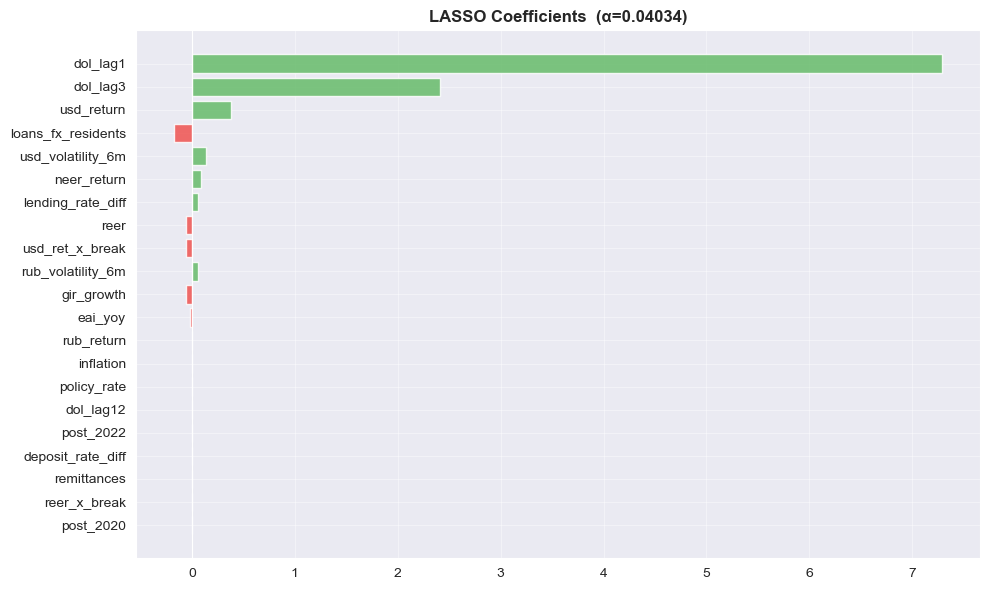

Selected: 12 / 21 variables


,Variable,Coefficient
13,eai_yoy,-0.0228
11,gir_growth,-0.0555
10,rub_volatility_6m,0.0597
19,usd_ret_x_break,-0.0598
0,reer,-0.0615
4,lending_rate_diff,0.0625
12,neer_return,0.0925
5,usd_volatility_6m,0.1413
1,loans_fx_residents,-0.1713
7,usd_return,0.3820


In [60]:
# ── LASSO coefficients────────────
scaler_full  = StandardScaler()
X_scaled_all = scaler_full.fit_transform(X_m)

lasso_full   = LassoCV(cv=5, max_iter=10000, random_state=42)
lasso_full.fit(X_scaled_all, y_m)

coef_df = pd.DataFrame({
    'Variable':   LASSO_VARS,
    'Coefficient':lasso_full.coef_
}).sort_values('Coefficient', key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors  = ['#ef5350' if c < 0 else '#66bb6a' for c in coef_df['Coefficient']]
ax.barh(coef_df['Variable'], coef_df['Coefficient'], color=colors, alpha=0.85)
ax.axvline(0, color='white', linewidth=0.8)
ax.set_title(f'LASSO Coefficients  (α={lasso_full.alpha_:.5f})', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'lasso_coefficients.png'), dpi=150, bbox_inches='tight')
plt.show()

selected = coef_df[coef_df['Coefficient'] != 0]
print(f'Selected: {len(selected)} / {len(LASSO_VARS)} variables')
display(selected.round(4))


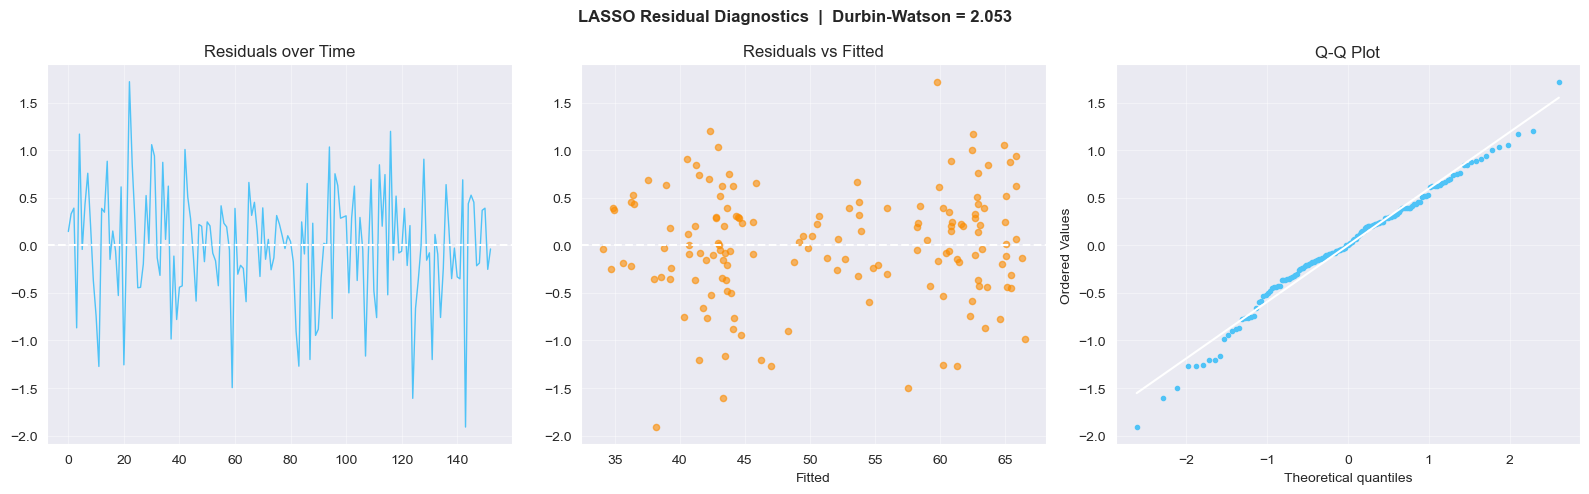

Durbin-Watson: 2.053  (2.0 = no autocorrelation)


In [61]:
# ──Residual diagnostics ────────────────────────────────────────────
residuals = y_m - lasso_full.predict(X_scaled_all)
dw        = durbin_watson(residuals)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].plot(residuals, color='#4fc3f7', linewidth=1)
axes[0].axhline(0, color='white', linestyle='--')
axes[0].set_title('Residuals over Time')

axes[1].scatter(lasso_full.predict(X_scaled_all), residuals,
                color='#fb8c00', alpha=0.6, s=20)
axes[1].axhline(0, color='white', linestyle='--')
axes[1].set_title('Residuals vs Fitted')
axes[1].set_xlabel('Fitted')

scipy_stats.probplot(residuals, plot=axes[2])
axes[2].set_title('Q-Q Plot')
axes[2].get_lines()[0].set(color='#4fc3f7', markersize=3)
axes[2].get_lines()[1].set(color='white')

plt.suptitle(f'LASSO Residual Diagnostics  |  Durbin-Watson = {dw:.3f}',
             fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'lasso_residuals.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Durbin-Watson: {dw:.3f}  (2.0 = no autocorrelation)')


## Phase 7 — ARDL / Error Correction Model


In [62]:
# ── ARDL setup ────────────────────────────────────────────────────
ardl_vars = LASSO_VARS.copy()

df_ardl = (df_model[['Date', TARGET] + ardl_vars]
           .dropna().sort_values('Date')
           .reset_index(drop=True)
           .drop(columns='Date'))


In [63]:
# ── Cointegration Check ─────────────────────────────────────────────

ardl_fit = ARDL(
    df_ardl[TARGET], lags=1,
    exog=df_ardl[ardl_vars],
    order={v: 1 for v in ardl_vars},
    trend='c'
).fit(cov_type='HC1')

print(ardl_fit.summary())

print('\n=== Cointegration Check ===')

l1_coef = ardl_fit.params.get(f'{TARGET}.L1', np.nan)
l1_pval = ardl_fit.pvalues.get(f'{TARGET}.L1', np.nan)

print(f'Lagged dependent variable (L1):')
print(f'  Coefficient : {l1_coef:.4f}')
print(f'  p-value     : {l1_pval:.4f}')
print(f'  Persistence : {"High — close to unit root" if l1_coef > 0.9 else "Moderate"}')

if l1_pval < 0.05 and l1_coef < 1:
    print('✅ L1 significant and <1 → long-run mean reversion exists → ECM appropriate')
else:
    print('⚠️  Interpret ARDL in levels only')

                                                        ARDL Model Results                                                        
Dep. Variable:                                                   d2_deposit_dollarization   No. Observations:                  153
Model:             ARDL(1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1)   Log Likelihood                -111.896
Method:                                                                   Conditional MLE   S.D. of innovations              0.505
Date:                                                                    Sun, 15 Mar 2026   AIC                            313.792
Time:                                                                            23:21:33   BIC                            449.867
Sample:                                                                                 1   HQIC                           369.070
                                                                                   

In [64]:
# ── ARDL walk-forward CV  ───────────────────
ardl_preds     = np.full(len(df_model), np.nan)
ardl_fold_mets = []
X_arr          = df_model[ardl_vars].values
y_arr          = df_model[TARGET].values

for fold, (tr, te) in enumerate(tscv.split(X_arr)):
    try:
        train_df = df_ardl.iloc[tr].copy().reset_index(drop=True)
        test_df  = df_ardl.iloc[te].copy().reset_index(drop=True)

        preds        = []
        history_y    = list(train_df[TARGET].values)
        history_exog = {v: list(train_df[v].values) for v in ardl_vars}

        for i in range(len(te)):
            # Build expanding training set
            temp_y    = pd.Series(history_y)
            temp_exog = pd.DataFrame(history_exog)

            # Refit on expanding window
            temp_m = ARDL(
                temp_y, lags=1,
                exog=temp_exog,
                order={v: 1 for v in ardl_vars},
                trend='c'
            ).fit(cov_type='HC1')

            next_exog = pd.DataFrame(
                {v: [test_df[v].iloc[i]] for v in ardl_vars}
            )
            try:
                yp = temp_m.forecast(steps=1, exog=next_exog).iloc[0]
            except:
                yp = temp_m.forecast(steps=1, exog_oos=next_exog).iloc[0]


            last_known = history_y[-1]
            yp = np.clip(yp, last_known - 10, last_known + 10)

            preds.append(yp)

            # Update history with ACTUAL observed value
            history_y.append(y_arr[te[i]])
            for v in ardl_vars:
                history_exog[v].append(test_df[v].iloc[i])

        preds_arr      = np.array(preds)
        ardl_preds[te] = preds_arr
        y_te           = y_arr[te]

        r = {'Fold': fold+1,
             'RMSE': np.sqrt(mean_squared_error(y_te, preds_arr)),
             'MAE':  mean_absolute_error(y_te, preds_arr),
             'R²':   r2_score(y_te, preds_arr)}
        ardl_fold_mets.append(r)
        print(f'  Fold {fold+1}: RMSE={r["RMSE"]:.4f}  '
              f'MAE={r["MAE"]:.4f}  R²={r["R²"]:.4f}')

    except Exception as e:
        print(f'  Fold {fold+1} error: {e}')
        ardl_fold_mets.append(
            {'Fold':fold+1,'RMSE':np.nan,'MAE':np.nan,'R²':np.nan})

ardl_cv_df = pd.DataFrame(ardl_fold_mets)
ardl_cv_df.loc['Mean'] = ardl_cv_df.mean()
print('\n=== ARDL Walk-Forward CV (rolling one-step-ahead) ===')
display(ardl_cv_df.round(4))

  Fold 1: RMSE=1.1446  MAE=0.9135  R²=-1.7694
  Fold 2: RMSE=1.3461  MAE=0.9859  R²=-2.9506
  Fold 3: RMSE=1.6874  MAE=1.1425  R²=-0.9268
  Fold 4: RMSE=0.6120  MAE=0.5401  R²=0.6766
  Fold 5: RMSE=0.7885  MAE=0.5885  R²=0.5772

=== ARDL Walk-Forward CV (rolling one-step-ahead) ===


,Fold,RMSE,MAE,R²
0,1.0,1.1446,0.9135,-1.7694
1,2.0,1.3461,0.9859,-2.9506
2,3.0,1.6874,1.1425,-0.9268
3,4.0,0.6120,0.5401,0.6766
4,5.0,0.7885,0.5885,0.5772
Mean,3.0,1.1157,0.8341,-0.8786


In [65]:
# ── HAR Model (Heterogeneous Autoregressive) ──────────────────────────────────
# Uses 1-month, 3-month, 12-month lags simultaneously
har_preds     = np.full(len(y_m), np.nan)
har_fold_mets = []

# Build HAR features
df_har              = df_model[['Date', TARGET]].copy()
df_har['har_lag1']  = df_har[TARGET].shift(1)
df_har['har_lag3']  = df_har[TARGET].shift(1).rolling(3).mean()
df_har['har_lag12'] = df_har[TARGET].shift(1).rolling(12).mean()
df_har = df_har.dropna().reset_index(drop=True)

X_har = df_har[['har_lag1','har_lag3','har_lag12']].values
y_har = df_har[TARGET].values

offset = len(y_m) - len(y_har)
assert offset == 12, f'HAR offset is {offset}, expected 12'

for fold, (tr, te) in enumerate(TimeSeriesSplit(n_splits=5, test_size=12).split(X_har)):
    X_tr = add_constant(X_har[tr])
    X_te = add_constant(X_har[te])
    model = OLS(y_har[tr], X_tr).fit()
    yp    = model.predict(X_te)
    har_preds[te + offset] = yp
    r = {'Fold':fold+1,
         'RMSE': np.sqrt(mean_squared_error(y_har[te], yp)),
         'MAE':  mean_absolute_error(y_har[te], yp),
         'R²':   r2_score(y_har[te], yp)}
    har_fold_mets.append(r)
    print(f'  Fold {fold+1}: RMSE={r["RMSE"]:.4f}  MAE={r["MAE"]:.4f}  R²={r["R²"]:.4f}')

har_cv_df = pd.DataFrame(har_fold_mets)
har_cv_df.loc['Mean'] = har_cv_df.mean()
print('\n=== HAR Walk-Forward CV ===')
display(har_cv_df.round(4))

  Fold 1: RMSE=0.7983  MAE=0.6432  R²=-0.3472
  Fold 2: RMSE=0.9117  MAE=0.7319  R²=-0.8121
  Fold 3: RMSE=0.6703  MAE=0.4883  R²=0.6960
  Fold 4: RMSE=0.5585  MAE=0.4537  R²=0.7307
  Fold 5: RMSE=0.6987  MAE=0.5093  R²=0.6680

=== HAR Walk-Forward CV ===


,Fold,RMSE,MAE,R²
0,1.0,0.7983,0.6432,-0.3472
1,2.0,0.9117,0.7319,-0.8121
2,3.0,0.6703,0.4883,0.6960
3,4.0,0.5585,0.4537,0.7307
4,5.0,0.6987,0.5093,0.6680
Mean,3.0,0.7275,0.5653,0.1871


## Phase 8 — VAR (Vector Autoregression)

In [66]:
# ── VAR (Vector Autoregression, AIC lag selection) ────────────────────────────

from statsmodels.tsa.api import VAR

VAR_VARS = ['reer', 'deposit_rate_diff', 'usd_volatility_6m',
             'policy_rate', 'inflation', TARGET]
VAR_VARS = [v for v in VAR_VARS if v in df_model.columns]

df_VAR       = df_model[VAR_VARS].dropna().reset_index(drop=True)
VAR_preds    = np.full(len(df_VAR), np.nan)
VAR_fold_mets = []
target_idx    = VAR_VARS.index(TARGET)

for fold, (tr, te) in enumerate(TimeSeriesSplit(n_splits=5, test_size=12).split(df_VAR.values)):
    try:
        train_data = df_VAR.iloc[tr].values

        var_model  = VAR(train_data)
        lag_order  = var_model.select_order(maxlags=4)
        best_lag   = max(1, min(lag_order.selected_orders.get('aic', 1), 4))

        var_fit    = var_model.fit(best_lag, trend='c')

        forecast   = var_fit.forecast(train_data[-best_lag:], steps=len(te))
        yp         = forecast[:, target_idx]
        y_te       = df_VAR.iloc[te][TARGET].values

        VAR_preds[te] = yp
        r = {'Fold':fold+1,
             'RMSE': np.sqrt(mean_squared_error(y_te, yp)),
             'MAE':  mean_absolute_error(y_te, yp),
             'R²':   r2_score(y_te, yp),
             'Lags': best_lag}
        VAR_fold_mets.append(r)
        print(f'  Fold {fold+1}: RMSE={r["RMSE"]:.4f}  MAE={r["MAE"]:.4f}  '
              f'R²={r["R²"]:.4f}  lags={best_lag}')
    except Exception as e:
        print(f'  Fold {fold+1} error: {e}')
        VAR_fold_mets.append({'Fold':fold+1,'RMSE':np.nan,'MAE':np.nan,'R²':np.nan,'Lags':np.nan})

VAR_cv_df = pd.DataFrame(VAR_fold_mets)
VAR_cv_df.loc['Mean'] = VAR_cv_df.mean()
print('\n=== VAR Walk-Forward CV ===')
display(VAR_cv_df.round(4))

VAR_preds_aligned = np.full(len(y_m), np.nan)
offset = len(y_m) - len(df_VAR)
VAR_preds_aligned[offset:] = VAR_preds

  Fold 1: RMSE=3.4009  MAE=3.0980  R²=-23.4485  lags=3
  Fold 2: RMSE=0.8460  MAE=0.6095  R²=-0.5602  lags=1
  Fold 3: RMSE=2.7258  MAE=1.9443  R²=-4.0280  lags=1
  Fold 4: RMSE=1.8069  MAE=1.6138  R²=-1.8191  lags=1
  Fold 5: RMSE=0.5147  MAE=0.4496  R²=0.8198  lags=1

=== VAR Walk-Forward CV ===


,Fold,RMSE,MAE,R²,Lags
0,1.0,3.4009,3.0980,-23.4485,3.0
1,2.0,0.8460,0.6095,-0.5602,1.0
2,3.0,2.7258,1.9443,-4.0280,1.0
3,4.0,1.8069,1.6138,-1.8191,1.0
4,5.0,0.5147,0.4496,0.8198,1.0
Mean,3.0,1.8589,1.5430,-5.8072,1.4


## Phase 10 — Final Comparison, DM Test & Sub-Period Analysis


In [67]:
# ── Metrics helper ───────────────────────────────────────────────────
def oos_metrics(y_true, y_pred, name):
    mask = ~np.isnan(y_pred)
    if mask.sum() < 5:
        return {'Model':name,'RMSE':np.nan,'MAE':np.nan,
                'R²':np.nan,'MAPE (%)':np.nan,'Dir. Accuracy (%)':np.nan}
    yt, yp = y_true[mask], y_pred[mask]
    return {
        'Model':             name,
        'RMSE':              np.sqrt(mean_squared_error(yt, yp)),
        'MAE':               mean_absolute_error(yt, yp),
        'R²':                r2_score(yt, yp),
        'MAPE (%)':          np.mean(np.abs((yt-yp)/(np.abs(yt)+1e-8)))*100,
        'Dir. Accuracy (%)': np.mean(np.sign(np.diff(yt))==np.sign(np.diff(yp)))*100
    }


In [68]:
# ──Final comparison table ───────────────────────────────────────────
comparison = pd.DataFrame([
    oos_metrics(y_m, rw_preds,          'Random Walk (Naive)'),
    oos_metrics(y_m, rm_preds,          'Rolling Mean (Naive)'),
    oos_metrics(y_m, lasso_preds,       'LASSO'),
    oos_metrics(y_m, ridge_preds,       'Ridge'),
    oos_metrics(y_m, enet_preds,        'Elastic Net'),
    oos_metrics(y_m, ardl_preds,        'ARDL/ECM'),
    oos_metrics(y_m, har_preds,         'HAR'),
    oos_metrics(y_m, VAR_preds_aligned,'VAR'),
]).sort_values('RMSE', na_position='last').reset_index(drop=True)

comparison.index        = comparison.index + 1
target_range            = y_m.max() - y_m.min()
comparison['NRMSE (%)'] = (comparison['RMSE'] / target_range * 100).round(2)

# ── Full table ────────────────────────────────────────────────────────────────
print('=== FULL MODEL COMPARISON ===')
print(f'Target range: {y_m.min():.1f}% – {y_m.max():.1f}%  ({target_range:.1f}pp)\n')
display(
    comparison.style
    .background_gradient(subset=['RMSE','MAE','MAPE (%)','NRMSE (%)'], cmap='RdYlGn_r')
    .background_gradient(subset=['R²','Dir. Accuracy (%)'],            cmap='RdYlGn')
    .format({'RMSE':'{:.4f}','MAE':'{:.4f}','R²':'{:.4f}',
             'MAPE (%)':'{:.2f}','Dir. Accuracy (%)':'{:.1f}',
             'NRMSE (%)':'{:.2f}'}, na_rep='—')
)

# ── Table 1: Level forecasting ────────────────────────────────────────────────
print('\n=== TABLE 1: LEVEL FORECASTING (Primary metric: RMSE) ===')
level_table = comparison[['Model','RMSE','MAE','NRMSE (%)']].copy()
display(level_table.sort_values('RMSE').round(4).reset_index(drop=True))

# ── Table 2: Directional forecasting ─────────────────────────────────────────
print('\n=== TABLE 2: DIRECTIONAL FORECASTING (Primary metric: Dir. Accuracy) ===')
dir_table = comparison[['Model','Dir. Accuracy (%)']].copy()
dir_table = dir_table[~dir_table['Model'].str.contains('Naive')]
display(dir_table.sort_values('Dir. Accuracy (%)',
        ascending=False).round(1).reset_index(drop=True))

=== FULL MODEL COMPARISON ===
Target range: 34.0% – 66.8%  (32.8pp)



,Model,RMSE,MAE,R²,MAPE (%),Dir. Accuracy (%),NRMSE (%)
1,HAR,0.7373,0.5653,0.9376,1.38,50.8,2.25
2,LASSO,0.9836,0.7770,0.8889,1.88,50.8,3.00
3,Elastic Net,1.0660,0.8271,0.8695,2.00,55.9,3.25
4,ARDL/ECM,1.1803,0.8341,0.8400,2.01,52.5,3.60
5,Ridge,1.2441,0.9630,0.8222,2.33,57.6,3.80
6,Random Walk (Naive),1.7028,1.3336,0.6670,3.40,1.7,5.20
7,VAR,2.1560,1.5430,0.4661,3.70,57.6,6.58
8,Rolling Mean (Naive),2.4619,2.0779,0.3039,5.32,6.8,7.51



=== TABLE 1: LEVEL FORECASTING (Primary metric: RMSE) ===


,Model,RMSE,MAE,NRMSE (%)
0,HAR,0.7373,0.5653,2.25
1,LASSO,0.9836,0.7770,3.00
2,Elastic Net,1.0660,0.8271,3.25
3,ARDL/ECM,1.1803,0.8341,3.60
4,Ridge,1.2441,0.9630,3.80
5,Random Walk (Naive),1.7028,1.3336,5.20
6,VAR,2.1560,1.5430,6.58
7,Rolling Mean (Naive),2.4619,2.0779,7.51



=== TABLE 2: DIRECTIONAL FORECASTING (Primary metric: Dir. Accuracy) ===


,Model,Dir. Accuracy (%)
0,Ridge,57.6
1,VAR,57.6
2,Elastic Net,55.9
3,ARDL/ECM,52.5
4,HAR,50.8
5,LASSO,50.8


In [69]:
# ──Diebold-Mariano Test ─────────────────────────────────────────────
def diebold_mariano(y_true, pred_bench, pred_model, h=1):
    mask  = ~np.isnan(pred_bench) & ~np.isnan(pred_model)
    if mask.sum() < 10:
        return np.nan, np.nan
    e1    = y_true[mask] - pred_bench[mask]
    e2    = y_true[mask] - pred_model[mask]
    d     = e1**2 - e2**2
    n     = len(d)
    d_bar = np.mean(d)
    gamma0 = np.var(d, ddof=1)
    gammas = sum(2*(1 - k/(h+1)) * np.cov(d[k:], d[:-k])[0,1]
                 for k in range(1, h+1) if k < n)
    var_d  = (gamma0 + gammas) / n
    if var_d <= 0:
        return np.nan, np.nan
    dm_stat    = d_bar / np.sqrt(var_d)
    hlm_factor = np.sqrt((n+1-2*h+h*(h-1)/n)/n)
    dm_stat   *= hlm_factor
    p_val      = 2 * (1 - scipy_stats.t.cdf(abs(dm_stat), df=n-1))
    return round(dm_stat, 4), round(p_val, 4)

# ── DM Test 1: HAR vs all competitors (level forecasting) ────────────────────
print('=== DM TEST 1: HAR vs Competitors (Level Forecasting) ===')
print('H0: Equal forecast accuracy  H1: HAR is significantly better\n')

dm_level = [
    ('Random Walk',  rw_preds,           y_m),
    ('Rolling Mean', rm_preds,           y_m),
    ('LASSO',        lasso_preds,        y_m),
    ('Ridge',        ridge_preds,        y_m),
    ('Elastic Net',  enet_preds,         y_m),
    ('ARDL/ECM',     ardl_preds,         y_m),
    ('VAR',         VAR_preds_aligned, y_m),
]

dm_level_rows = []
for name, comp_preds, y_ref in dm_level:
    dm_stat, p_val = diebold_mariano(y_ref, comp_preds, har_preds)
    sig = '✅ HAR significantly better' if (not np.isnan(p_val) and p_val < 0.05) \
          else ('⚠️ No significant difference' if not np.isnan(p_val) else '—')
    dm_level_rows.append({'Competitor': name, 'DM Statistic': dm_stat,
                           'p-value': p_val, 'Result': sig})
    print(f'  HAR vs {name:<15} DM={str(dm_stat):<8} p={str(p_val):<8} {sig}')

display(pd.DataFrame(dm_level_rows))

# ── DM Test 2: Elastic Net vs all competitors (directional) ──────────────────
print('\n=== DM TEST 2: Elastic Net vs Competitors (Directional — RMSE basis) ===')
print('H0: Equal forecast accuracy  H1: Elastic Net is significantly better\n')

dm_dir = [
    ('Random Walk',  rw_preds,           y_m),
    ('Rolling Mean', rm_preds,           y_m),
    ('LASSO',        lasso_preds,        y_m),
    ('Ridge',        ridge_preds,        y_m),
    ('ARDL/ECM',     ardl_preds,         y_m),
    ('VAR',         VAR_preds_aligned, y_m),
    ('HAR',          har_preds,          y_m),
]

dm_dir_rows = []
for name, comp_preds, y_ref in dm_dir:
    dm_stat, p_val = diebold_mariano(y_ref, comp_preds, enet_preds)
    sig = '✅ Elastic Net significantly better' if (not np.isnan(p_val) and p_val < 0.05) \
          else ('⚠️ No significant difference' if not np.isnan(p_val) else '—')
    dm_dir_rows.append({'Competitor': name, 'DM Statistic': dm_stat,
                         'p-value': p_val, 'Result': sig})
    print(f'  ENet vs {name:<15} DM={str(dm_stat):<8} p={str(p_val):<8} {sig}')

display(pd.DataFrame(dm_dir_rows))

=== DM TEST 1: HAR vs Competitors (Level Forecasting) ===
H0: Equal forecast accuracy  H1: HAR is significantly better

  HAR vs Random Walk     DM=3.5865   p=0.0007   ✅ HAR significantly better
  HAR vs Rolling Mean    DM=4.1989   p=0.0001   ✅ HAR significantly better
  HAR vs LASSO           DM=2.1415   p=0.0364   ✅ HAR significantly better
  HAR vs Ridge           DM=2.7064   p=0.0089   ✅ HAR significantly better
  HAR vs Elastic Net     DM=2.5542   p=0.0132   ✅ HAR significantly better
  HAR vs ARDL/ECM        DM=2.2447   p=0.0285   ✅ HAR significantly better
  HAR vs VAR             DM=3.3592   p=0.0014   ✅ HAR significantly better


,Competitor,DM Statistic,p-value,Result
0,Random Walk,3.5865,0.0007,✅ HAR significantly better
1,Rolling Mean,4.1989,0.0001,✅ HAR significantly better
2,LASSO,2.1415,0.0364,✅ HAR significantly better
3,Ridge,2.7064,0.0089,✅ HAR significantly better
4,Elastic Net,2.5542,0.0132,✅ HAR significantly better
5,ARDL/ECM,2.2447,0.0285,✅ HAR significantly better
6,VAR,3.3592,0.0014,✅ HAR significantly better



=== DM TEST 2: Elastic Net vs Competitors (Directional — RMSE basis) ===
H0: Equal forecast accuracy  H1: Elastic Net is significantly better

  ENet vs Random Walk     DM=2.5315   p=0.014    ✅ Elastic Net significantly better
  ENet vs Rolling Mean    DM=3.5606   p=0.0007   ✅ Elastic Net significantly better
  ENet vs LASSO           DM=-2.2118  p=0.0309   ✅ Elastic Net significantly better
  ENet vs Ridge           DM=1.9054   p=0.0616   ⚠️ No significant difference
  ENet vs ARDL/ECM        DM=0.6055   p=0.5472   ⚠️ No significant difference
  ENet vs VAR             DM=3.1094   p=0.0029   ✅ Elastic Net significantly better
  ENet vs HAR             DM=-2.5542  p=0.0132   ✅ Elastic Net significantly better


,Competitor,DM Statistic,p-value,Result
0,Random Walk,2.5315,0.0140,✅ Elastic Net significantly better
1,Rolling Mean,3.5606,0.0007,✅ Elastic Net significantly better
2,LASSO,-2.2118,0.0309,✅ Elastic Net significantly better
3,Ridge,1.9054,0.0616,⚠️ No significant difference
4,ARDL/ECM,0.6055,0.5472,⚠️ No significant difference
5,VAR,3.1094,0.0029,✅ Elastic Net significantly better
6,HAR,-2.5542,0.0132,✅ Elastic Net significantly better


In [70]:
# ── Pre/Post 2022 Sub-Period Analysis ────────────────────────────────
print('=== SUB-PERIOD ANALYSIS: PRE vs POST 2022 ===\n')

dates    = df_model['Date'].values
break_dt = np.datetime64('2022-03-01')

sub_rows = []
for name, preds, y_ref, date_ref in [
    ('HAR',         har_preds,          y_m,   dates),
    ('VAR',        VAR_preds_aligned, y_m,   dates),
    ('LASSO',       lasso_preds,        y_m,   dates),
    ('Ridge',       ridge_preds,        y_m,   dates),
    ('Elastic Net', enet_preds,         y_m,   dates),
    ('ARDL/ECM',    ardl_preds,         y_m,   dates),
    ('Random Walk', rw_preds,           y_m,   dates),
]:
    for period, pmask in [('Pre-2022',  date_ref <  break_dt),
                           ('Post-2022', date_ref >= break_dt)]:
        m = ~np.isnan(preds) & pmask
        if m.sum() < 3:
            continue
        rmse = np.sqrt(mean_squared_error(y_ref[m], preds[m]))
        mae  = mean_absolute_error(y_ref[m], preds[m])
        sub_rows.append({'Model':name,'Period':period,
                          'N':m.sum(),'RMSE':round(rmse,4),'MAE':round(mae,4)})

sub_df    = pd.DataFrame(sub_rows)
sub_pivot = sub_df.pivot_table(index='Model', columns='Period',
                                values=['RMSE','MAE'], aggfunc='first')
display(sub_pivot.round(4))
print('\nModels with lower Post-2022 RMSE handled the structural break better.')

=== SUB-PERIOD ANALYSIS: PRE vs POST 2022 ===



MAE               RMSE         
Period      Post-2022 Pre-2022 Post-2022 Pre-2022
Model                                            
ARDL/ECM       0.8153   0.8818    1.2087   1.1054
Elastic Net    0.6716   1.2202    0.8988   1.4027
HAR            0.5631   0.5710    0.7463   0.7138
LASSO          0.6398   1.1240    0.8155   1.3162
Random Walk    1.5344   0.8257    1.8979   1.0594
Ridge          0.7108   1.6009    0.9238   1.8177
VAR            1.2545   2.2728    1.8011   2.8637


Models with lower Post-2022 RMSE handled the structural break better.


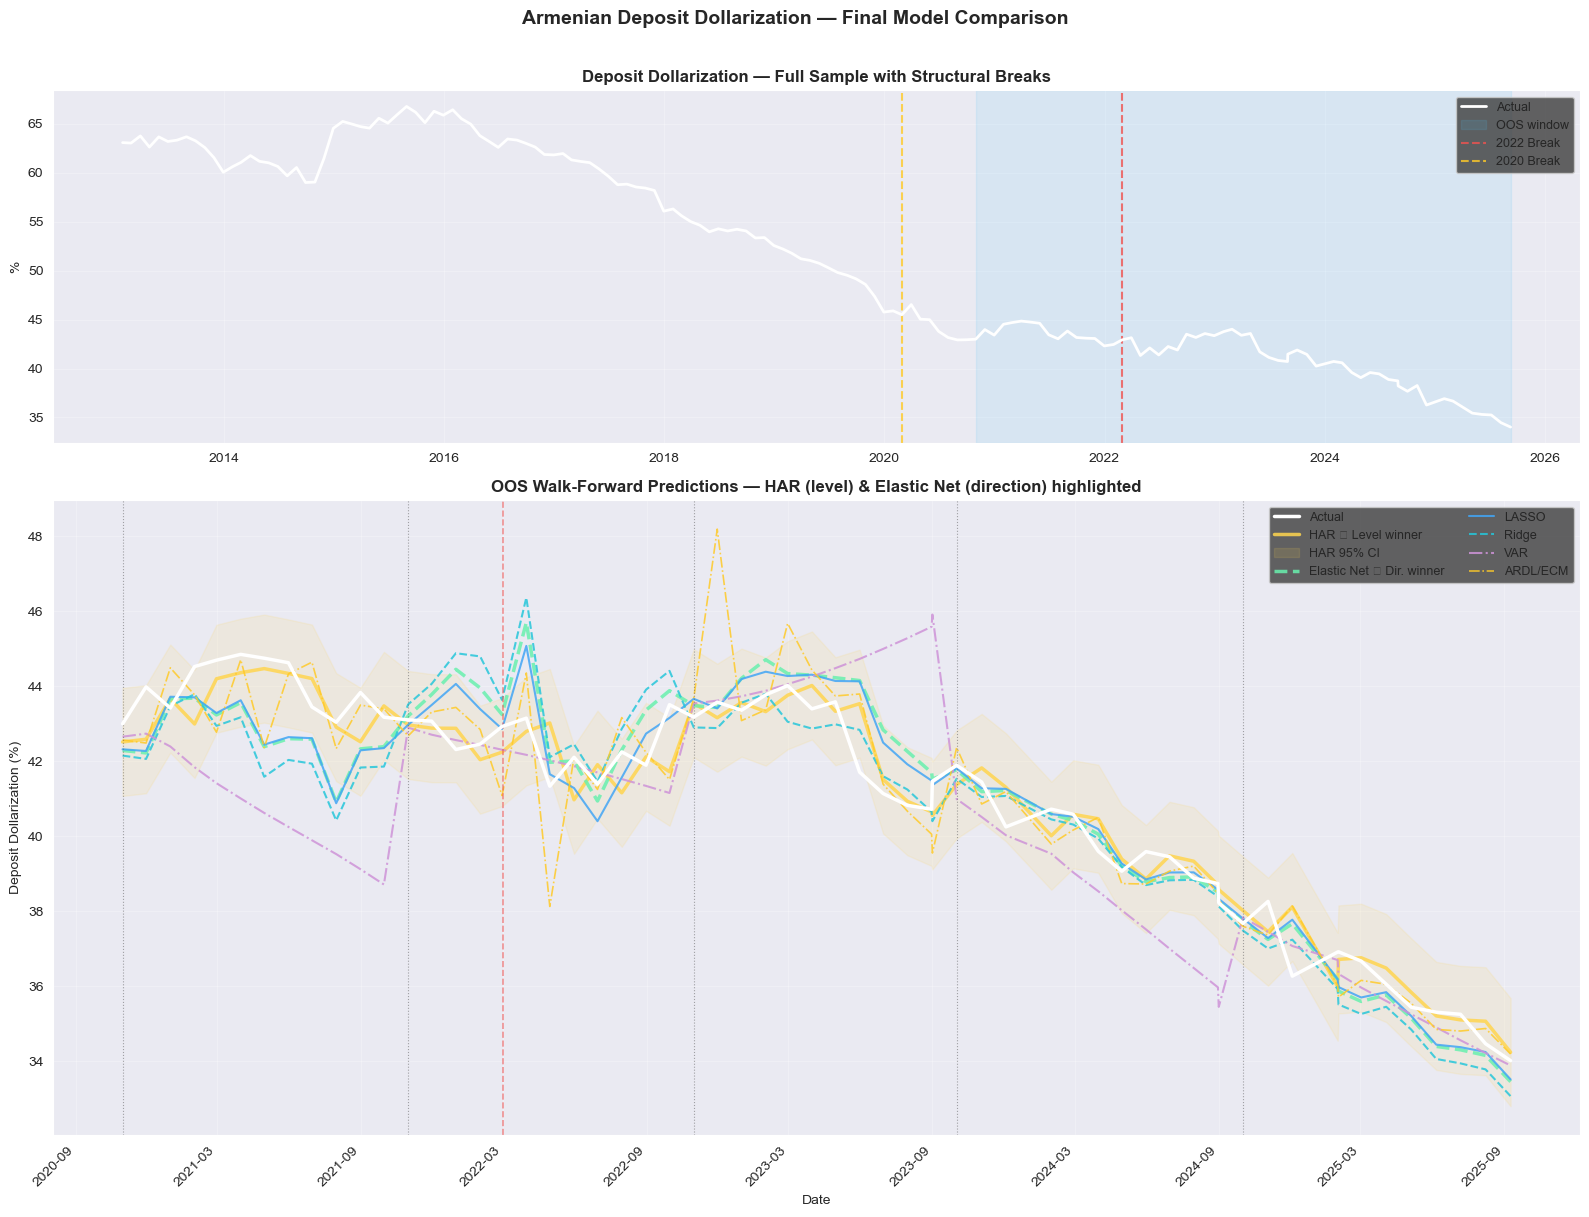

In [71]:
# ──Final forecast plot ──────────────────────────────────────────────
dates          = df_model['Date'].values
oos_mask       = ~np.isnan(lasso_preds)
oos_start_date = dates[oos_mask][0]
oos_date_mask  = dates >= oos_start_date

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12),
                                gridspec_kw={'height_ratios':[1, 1.8]})

# Panel 1: Full series
ax1.plot(dates, y_m, color='white', linewidth=2, zorder=5, label='Actual')
ax1.axvspan(oos_start_date, dates[-1], alpha=0.12, color='#4fc3f7',
            label='OOS window')
ax1.axvline(np.datetime64('2022-03-01'), color='#ef5350',
            linewidth=1.5, linestyle='--', alpha=0.8, label='2022 Break')
if include_2020:
    ax1.axvline(np.datetime64('2020-03-01'), color='#ffca28',
                linewidth=1.5, linestyle='--', alpha=0.8, label='2020 Break')
ax1.set_title('Deposit Dollarization — Full Sample with Structural Breaks',
              fontweight='bold', fontsize=12)
ax1.set_ylabel('%')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(True, alpha=0.25)

# Panel 2: OOS predictions
ax2.plot(dates[oos_date_mask], y_m[oos_date_mask],
         color='white', linewidth=2.5, zorder=5, label='Actual')

model_plots = [
    # Winners highlighted with thicker lines
    ('HAR ★ Level winner',       har_preds,          '#ffd54f', '-',  2.5, True),
    ('Elastic Net ★ Dir. winner',enet_preds,          '#69f0ae', '--', 2.5, False),
    # Other models thinner
    ('LASSO',                    lasso_preds,         '#42a5f5', '-',  1.5, False),
    ('Ridge',                    ridge_preds,         '#26c6da', '--', 1.5, False),
    ('VAR',                     VAR_preds_aligned,  '#ce93d8', '-.', 1.5, False),
    ('ARDL/ECM',                 ardl_preds,          '#ffca28', '-.', 1.2, False),
]

for name, preds, color, ls, lw, add_ci in model_plots:
    mask = ~np.isnan(preds) & oos_date_mask
    if mask.sum() == 0:
        continue
    ax2.plot(dates[mask], preds[mask], linewidth=lw,
             color=color, alpha=0.85, linestyle=ls, label=name)
    if add_ci:
        errors  = y_m[mask] - preds[mask]
        std_err = np.std(errors)
        ax2.fill_between(dates[mask],
                         preds[mask] - 1.96 * std_err,
                         preds[mask] + 1.96 * std_err,
                         alpha=0.12, color=color, label='HAR 95% CI')

# Fold boundaries
for _, te in tscv.split(X_m):
    fb = dates[te[0]]
    if fb >= oos_start_date:
        ax2.axvline(fb, color='#555', linewidth=0.8, linestyle=':', alpha=0.5)

ax2.axvline(np.datetime64('2022-03-01'), color='#ef5350',
            linewidth=1.2, linestyle='--', alpha=0.6)
ax2.set_title('OOS Walk-Forward Predictions — HAR (level) & Elastic Net (direction) highlighted',
              fontweight='bold', fontsize=12)
ax2.set_ylabel('Deposit Dollarization (%)')
ax2.set_xlabel('Date')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax2.legend(fontsize=9, loc='upper right', ncol=2)
ax2.grid(True, alpha=0.25)

plt.suptitle('Armenian Deposit Dollarization — Final Model Comparison',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'all_model_predictions_final.png'), dpi=150, bbox_inches='tight')
plt.show()

In [72]:
# Save all results to Excel ────────────────────────────────────────
out_path = os.path.join(OUTPUT_DIR, 'modelling_results.xlsx')

with pd.ExcelWriter(out_path, engine='openpyxl') as writer:
    comparison.to_excel(writer,   sheet_name='Full_Comparison',       index=True)
    level_table.to_excel(writer,  sheet_name='Level_Forecasting',     index=False)
    dir_table.to_excel(writer,    sheet_name='Directional_Forecasting',index=False)
    chow_df.to_excel(writer,      sheet_name='Chow_Tests')
    sub_pivot.to_excel(writer,    sheet_name='SubPeriod_Analysis')
    pd.DataFrame(dm_level_rows).to_excel(writer, sheet_name='DM_Level',  index=False)
    pd.DataFrame(dm_dir_rows).to_excel(writer,   sheet_name='DM_Direction',index=False)

    pred_df              = df_model[['Date', TARGET]].copy()
    pred_df['HAR']       = har_preds
    pred_df['Elastic_Net']= enet_preds
    pred_df['LASSO']     = lasso_preds
    pred_df['Ridge']     = ridge_preds
    pred_df['VAR']      = VAR_preds_aligned
    pred_df['ARDL_ECM']  = ardl_preds
    pred_df['RW_Naive']  = rw_preds
    pred_df['RM_Naive']  = rm_preds
    pred_df.to_excel(writer, sheet_name='All_Predictions', index=False)

    for name, dff in [
        ('LASSO_CV',      lasso_cv_df),
        ('Ridge_CV',      ridge_cv_df),
        ('ElasticNet_CV', enet_cv_df),
        ('ARDL_CV',       ardl_cv_df),
        ('HAR_CV',        har_cv_df),
        ('VAR_CV',       VAR_cv_df),
        ('RandomWalk_CV', rw_df),
        ('RollingMean_CV',rm_df),
    ]:
        dff.to_excel(writer, sheet_name=name)

    coef_df.to_excel(writer, sheet_name='LASSO_Coefficients', index=False)

print(f'✅ Saved: {out_path}')

✅ Saved: Outputs\modelling_results.xlsx


In [73]:
# Final summary ─────────────────────────────────────────────────────
print('=' * 65)
print('THESIS RESULTS SUMMARY')
print('Armenian Deposit Dollarization Forecasting | 2012-2025')
print('=' * 65)

har_row  = comparison[comparison['Model']=='HAR'].iloc[0]
enet_row = comparison[comparison['Model']=='Elastic Net'].iloc[0]
rw_row   = comparison[comparison['Model']=='Random Walk (Naive)'].iloc[0]

print(f'\n── LEVEL FORECASTING ──')
print(f'Winner       : HAR')
print(f'RMSE         : {har_row["RMSE"]:.4f} pp')
print(f'MAE          : {har_row["MAE"]:.4f} pp')
print(f'NRMSE        : {har_row["NRMSE (%)"]:.2f}% of target range')
print(f'vs Naive RW  : {((rw_row["RMSE"]-har_row["RMSE"])/rw_row["RMSE"]*100):.1f}% improvement')

print(f'\n── DIRECTIONAL FORECASTING ──')
print(f'Winner       : Elastic Net')
print(f'Dir.Accuracy : {enet_row["Dir. Accuracy (%)"]:.1f}%')
print(f'vs Random    : +{enet_row["Dir. Accuracy (%)"]-50:.1f}pp above 50% baseline')

print(f'\n── STRUCTURAL BREAKS ──')
print(f'post_2020    : {"Confirmed (Chow test)" if include_2020 else "Not confirmed"}')
print(f'post_2022    : {"Confirmed (Chow test)" if include_2022 else "Not confirmed"}')

print(f'\nAll results saved → modelling_results.xlsx')
print('=' * 65)

THESIS RESULTS SUMMARY
Armenian Deposit Dollarization Forecasting | 2012-2025

── LEVEL FORECASTING ──
Winner       : HAR
RMSE         : 0.7373 pp
MAE          : 0.5653 pp
NRMSE        : 2.25% of target range
vs Naive RW  : 56.7% improvement

── DIRECTIONAL FORECASTING ──
Winner       : Elastic Net
Dir.Accuracy : 55.9%
vs Random    : +5.9pp above 50% baseline

── STRUCTURAL BREAKS ──
post_2020    : Confirmed (Chow test)
post_2022    : Confirmed (Chow test)

All results saved → modelling_results.xlsx
